# Portfolio Analysis and Risk Metrics

Computes full risk metrics (VaR, CVaR, Sharpe, Sortino, Calmar, drawdown) for both
an equal-weight and an optimised portfolio derived from the stocks in config.yaml.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.utils.config import load_config
from src.analysis.portfolio import (
    calculate_portfolio_returns,
    calculate_cumulative_returns,
    calculate_correlation_matrix,
    calculate_covariance_matrix,
    minimum_variance_weights,
    maximum_sharpe_weights,
    portfolio_summary,
)
from src.analysis.risk_metrics import (
    calculate_var,
    calculate_cvar,
    calculate_sharpe_ratio,
    rolling_var,
    risk_summary,
)
from src.visualization.plots import (
    plot_portfolio_performance,
    plot_drawdown,
    plot_rolling_var,
    plot_efficient_frontier,
    plot_correlation_heatmap,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
cfg = load_config()
conf_level = cfg['risk_metrics']['var_confidence']
rf_rate    = 0.02

returns = pd.read_csv('../data/raw/stock_returns.csv', index_col='Date')
returns.index = pd.to_datetime(returns.index)
returns = returns.select_dtypes(include='number')

# Restrict to tickers that appear in config and exist in data
cfg_tickers = [t for t in cfg['stocks'] if t in returns.columns]
returns     = returns[cfg_tickers].dropna()

print(f'Tickers: {cfg_tickers}')
print(f'Rows:    {len(returns)}')
print(returns.tail(3))

Tickers: ['AAPL', 'MSFT', 'GOOGL', 'JNJ', 'JPM', 'XOM', 'AMZN', 'V', 'UNH', 'WMT', 'PFE']
Rows:    1255
                AAPL      MSFT     GOOGL       JNJ       JPM       XOM  \
Date                                                                     
2024-12-24  0.011478  0.009374  0.007604  0.003993  0.016444  0.000941   
2024-12-26  0.003176 -0.002777 -0.002601 -0.001851  0.003425  0.000846   
2024-12-27 -0.013242 -0.017302 -0.014519 -0.003641 -0.008102 -0.000094   

                AMZN         V       UNH       WMT       PFE  
Date                                                          
2024-12-24  0.017729  0.010813 -0.000474  0.025788  0.001123  
2024-12-26 -0.008732  0.000811  0.009978  0.001187 -0.006732  
2024-12-27 -0.014534 -0.007011 -0.002269 -0.012178  0.002259  


In [3]:
# Equal-weight portfolio
n = len(cfg_tickers)
equal_weights = np.ones(n) / n

eq_port_returns = calculate_portfolio_returns(returns, equal_weights)
eq_cum          = calculate_cumulative_returns(eq_port_returns)

print('Equal-weight portfolio summary:')
eq_summary = portfolio_summary(returns, equal_weights, risk_free_rate=rf_rate)
for k, v in eq_summary.items():
    print(f'  {k}: {v:.4f}')

Equal-weight portfolio summary:
  annualized_return: 0.1838
  annualized_volatility: 0.1996
  sharpe_ratio: 0.8209
  max_drawdown: -0.2902
  cumulative_return: 1.2610


In [4]:
# Optimised portfolios
mv_weights     = minimum_variance_weights(returns)
sharpe_weights = maximum_sharpe_weights(returns, risk_free_rate=rf_rate)

print('Minimum Variance weights:')
for t, w in zip(cfg_tickers, mv_weights):
    print(f'  {t}: {w:.4f}')

print('\nMaximum Sharpe weights:')
for t, w in zip(cfg_tickers, sharpe_weights):
    print(f'  {t}: {w:.4f}')

Minimum Variance weights:
  AAPL: 0.0909
  MSFT: 0.0909
  GOOGL: 0.0909
  JNJ: 0.0909
  JPM: 0.0909
  XOM: 0.0909
  AMZN: 0.0909
  V: 0.0909
  UNH: 0.0909
  WMT: 0.0909
  PFE: 0.0909

Maximum Sharpe weights:
  AAPL: 0.3000
  MSFT: 0.0000
  GOOGL: 0.1181
  JNJ: 0.0000
  JPM: 0.0000
  XOM: 0.1105
  AMZN: 0.0000
  V: 0.0000
  UNH: 0.0000
  WMT: 0.4713
  PFE: 0.0000


In [5]:
# Compare portfolio summaries
port_configs = [
    ('Equal Weight',     equal_weights),
    ('Min Variance',     mv_weights),
    ('Max Sharpe',       sharpe_weights),
]

rows = []
for name, w in port_configs:
    s = portfolio_summary(returns, w, risk_free_rate=rf_rate)
    s['portfolio'] = name
    rows.append(s)

comparison = pd.DataFrame(rows).set_index('portfolio')
print(comparison.round(4))

              annualized_return  annualized_volatility  sharpe_ratio  \
portfolio                                                              
Equal Weight             0.1838                 0.1996        0.8209   
Min Variance             0.1838                 0.1996        0.8209   
Max Sharpe               0.2411                 0.2050        1.0784   

              max_drawdown  cumulative_return  
portfolio                                      
Equal Weight       -0.2902             1.2610  
Min Variance       -0.2902             1.2610  
Max Sharpe         -0.2093             1.9902  


In [6]:
# Risk metrics for equal-weight portfolio
print('Risk metrics (equal-weight):')
rs = risk_summary(eq_port_returns, confidence=conf_level, risk_free_rate=rf_rate)
for k, v in rs.items():
    print(f'  {k}: {v:.4f}')

Risk metrics (equal-weight):
  var: 0.0165
  cvar: 0.0300
  sharpe_ratio: 0.8209
  sortino_ratio: 0.7806
  calmar_ratio: 0.6334
  annualized_return: 0.1838
  annualized_volatility: 0.1996


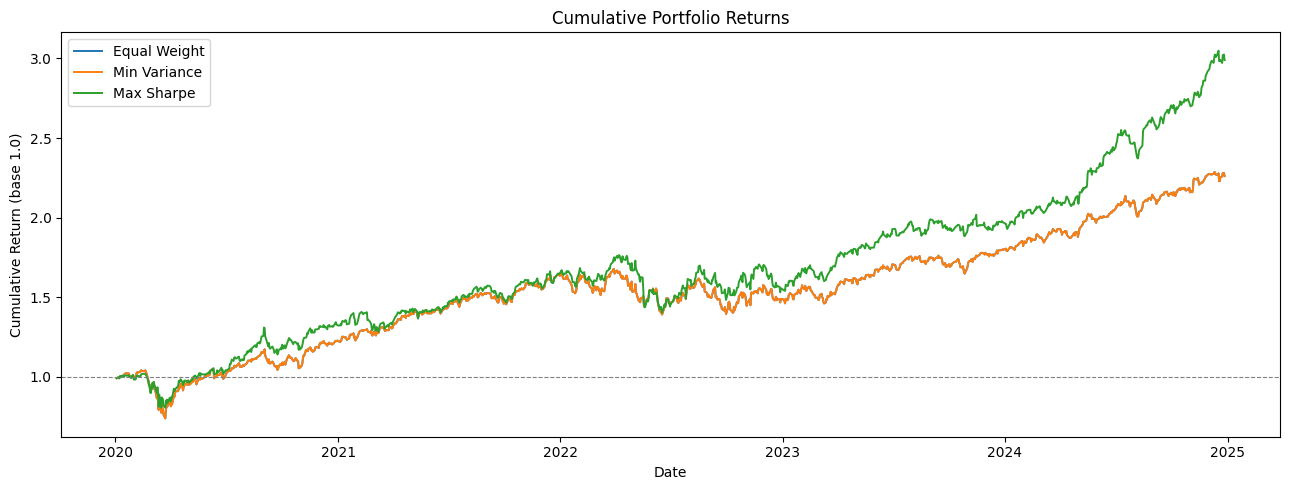

In [7]:
# Cumulative performance chart
fig, ax = plt.subplots(figsize=(13, 5))
for name, w in port_configs:
    pr = calculate_portfolio_returns(returns, w)
    cr = calculate_cumulative_returns(pr)
    ax.plot(cr.index, cr.values, label=name, linewidth=1.4)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Cumulative Portfolio Returns')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (base 1.0)')
ax.legend()
plt.tight_layout()
plt.show()

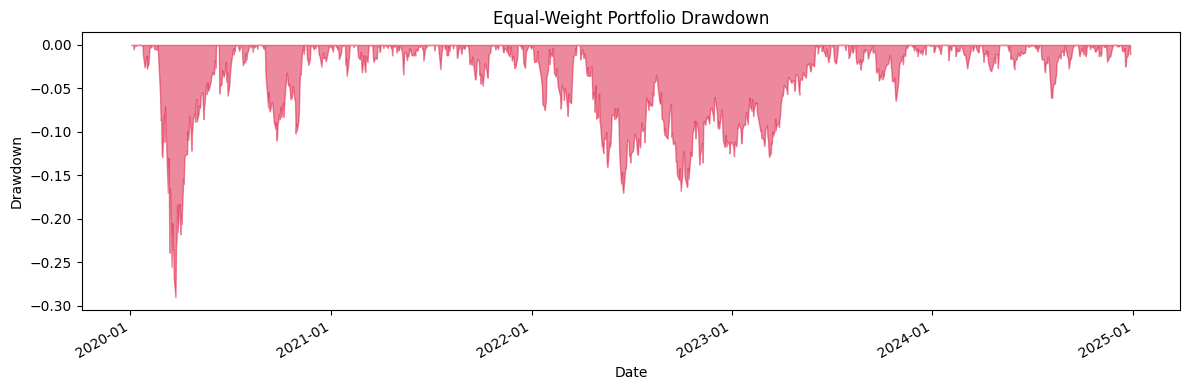

In [8]:
fig = plot_drawdown(eq_cum, title='Equal-Weight Portfolio Drawdown')
plt.show()

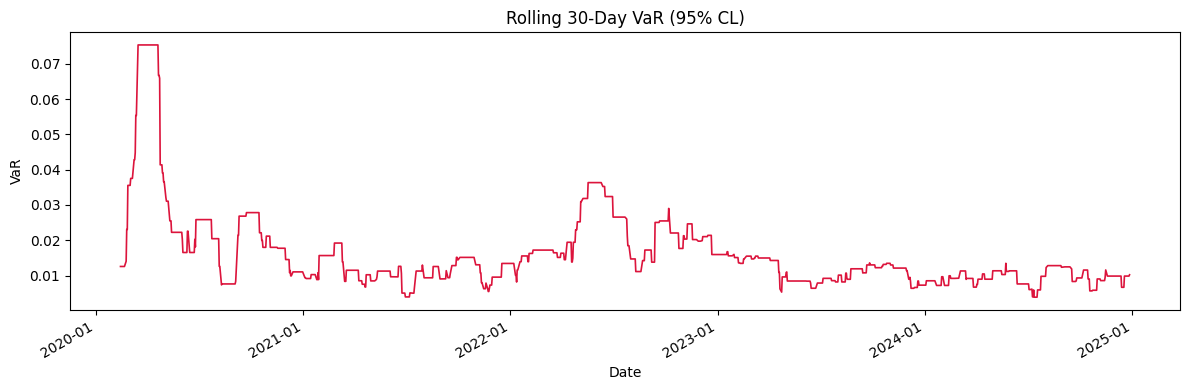

In [9]:
# Rolling 30-day VaR
roll_v = rolling_var(eq_port_returns, window=30, confidence=conf_level)
fig = plot_rolling_var(roll_v, title=f'Rolling 30-Day VaR ({int(conf_level*100)}% CL)')
plt.show()

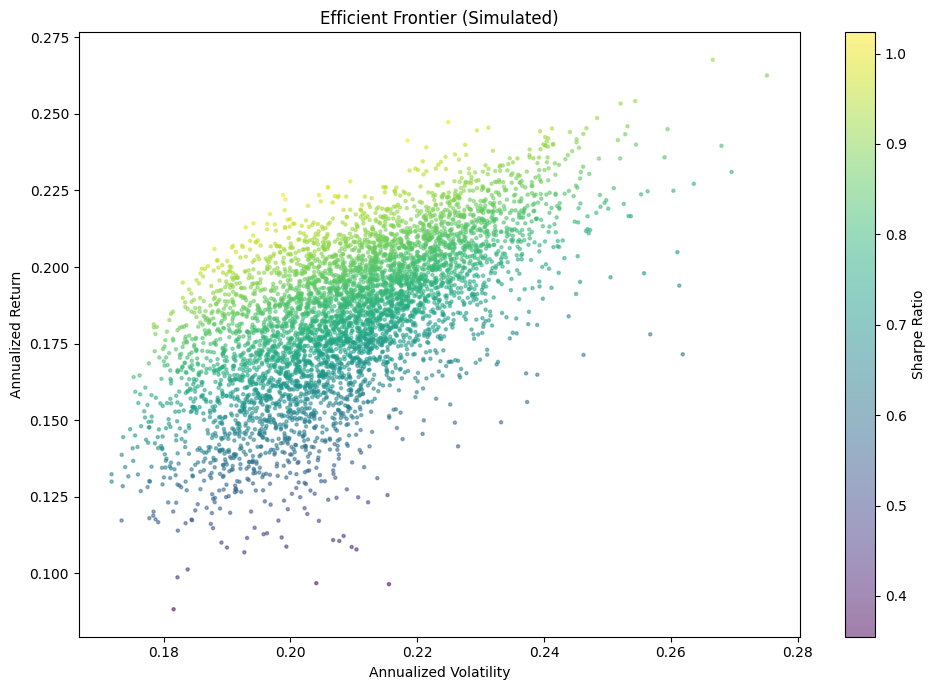

In [10]:
# Efficient frontier
ann_ret = returns.mean() * 252
cov_ann = calculate_covariance_matrix(returns, annualize=True)
fig = plot_efficient_frontier(ann_ret, cov_ann, n_portfolios=5000, risk_free_rate=rf_rate)
plt.show()

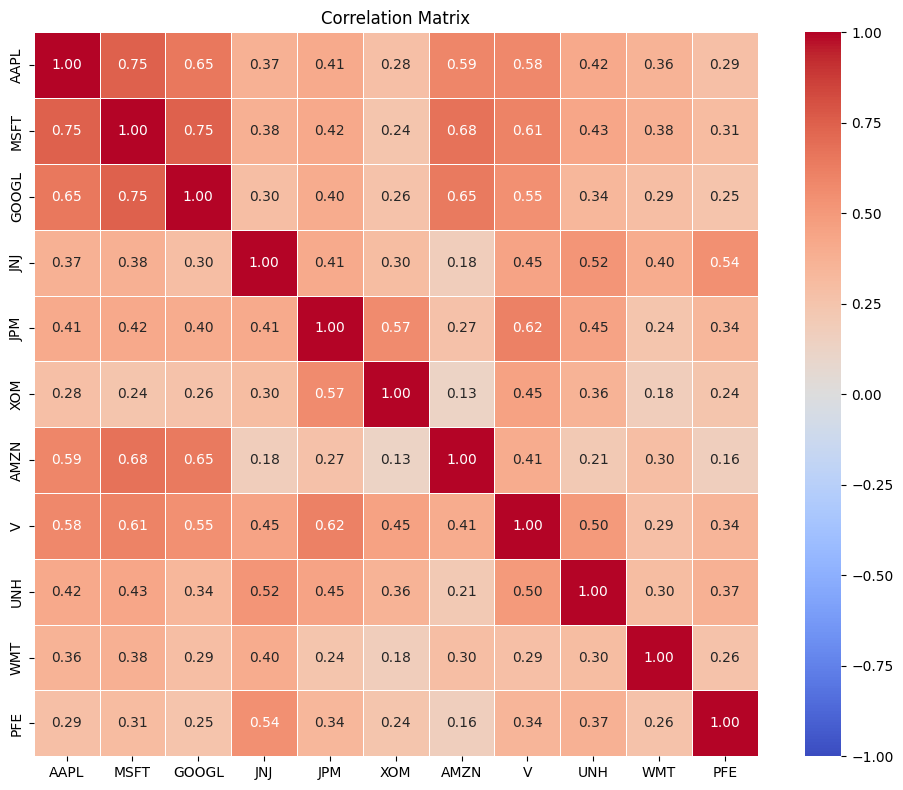

In [11]:
fig = plot_correlation_heatmap(calculate_correlation_matrix(returns))
plt.show()